# Self Attention

## Data Preparation

1) padding <pad> for making all sequences of same length in batch.  
2) unknown <unk> to handle any rare or out of vocabulary words the model might encounter during inference

In [4]:
import math
import os
import re 
import urllib.request
from collections import Counter
from typing import Callable, Dict, List, Optional, Sequence

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn   
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm


/home/mfaizan/personal/FROM_SCRATCH_ML/from_scratch/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:

# Tiny toy dataset
sentences = """
the dog chased the cat
the cat chased the mouse
the dog ran fast
the mouse ran fast
the cat lay down
"""

## build vocab
tokens = sentences.split()
vocab = ['<pad>','<unk>'] + sorted(set(tokens))
word2idx = {w: i for i, w in enumerate(vocab)}
idx2word = {i: w for i, w in enumerate(vocab)}
print(f"Vocab size: {len(vocab)}")

Vocab size: 11


In [6]:
## Tokenizer
## convert into root letters or basic unit from the word 
## and mapping tokens to indices

## Steps
#1) Coverting everything to lower case consistency
#2) Removing punctuation to focus on word embeddings
#3) Splitting on Whitespace and word boundaries


## Tokenizer

In [7]:
class SimpleTokenizer:
    """
    Splits on whitespace and lowercases, with optional regex for real word tokens.
    """

    def __init__(self):
        pass

    def __call__(self, text):
        text = text.lower()
        tokens = re.findall(r'\b\w+\b', text)
        return tokens




In [8]:
tokenizer  = SimpleTokenizer()
tokens = tokenizer("The Dog chased the Cat.")
print(tokens)

['the', 'dog', 'chased', 'the', 'cat']


## Building the Vocabulary

In [9]:
def build_vocab(sentences, tokenizer, min_freq = 1):

    counter = Counter()

    ## dictionary for word count
    for sent in sentences:
        counter.update(tokenizer(sent))

    ## creating vocab
    vocab = [w for w,c in counter.items() if c>=min_freq]
    vocab+=['<pad>','<unk>']

    ## word to index
    word2idx = {w: i for i, w in enumerate(vocab)}

    ## index to word
    idx2word = {i:w for i, w in enumerate(vocab)}

    return vocab, word2idx, idx2word


In [10]:
# Using our sample sentences and tokenizer
sentences = [
    "the dog chased the cat",
    "the cat chased the mouse",
    "the dog ran fast",
    "the mouse ran fast",
    "the cat lay down"
]
tokenizer = SimpleTokenizer()
vocab, word2idx, idx2word = build_vocab(sentences, tokenizer, min_freq=1)
print(f"Vocab: {vocab}")
print(f"Word to Index: {word2idx}")
print(f"Index to Word: {idx2word}")

Vocab: ['the', 'dog', 'chased', 'cat', 'mouse', 'ran', 'fast', 'lay', 'down', '<pad>', '<unk>']
Word to Index: {'the': 0, 'dog': 1, 'chased': 2, 'cat': 3, 'mouse': 4, 'ran': 5, 'fast': 6, 'lay': 7, 'down': 8, '<pad>': 9, '<unk>': 10}
Index to Word: {0: 'the', 1: 'dog', 2: 'chased', 3: 'cat', 4: 'mouse', 5: 'ran', 6: 'fast', 7: 'lay', 8: 'down', 9: '<pad>', 10: '<unk>'}


In [11]:
word = "cat"
idx = word2idx.get(word, word2idx['<unk>'])
print(f"Index of '{word}': {idx}")
print(f"Word for index {idx}: {idx2word[idx]}")

Index of 'cat': 3
Word for index 3: cat


## sliding Windows

**Predicting Next Word after Window**

In [12]:
## selecting fixed size window as input and train to predict the next word that follows the window in the sentence.
tokenizer = SimpleTokenizer()
vocab, word2idx, idx2word = build_vocab(sentences, tokenizer)

## 2
SEQ_LEN = 4

## 3
encoded_sentences = []
for sent in sentences:
    ## tokenizations
    tokens = tokenizer(sent)
    
    ## Map tokens to IDS
    ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]

    encoded_sentences.append(ids)

## 4 
inputs = []
targets = []
for ids in encoded_sentences:
    for i in range(len(ids)-SEQ_LEN):
        ## window length of SEQ_LEN
        window = ids[i:i+SEQ_LEN]

        ## Just next word after target
        target = ids[i+SEQ_LEN]

        inputs.append(window)
        targets.append(target)

## 5
for input , target in zip(inputs, targets):
    inp_words = [idx2word[i] for i in input]
    tgt_word = [idx2word[target]]

    print(f"Input: {inp_words} -> Target : {tgt_word}")



Input: ['the', 'dog', 'chased', 'the'] -> Target : ['cat']
Input: ['the', 'cat', 'chased', 'the'] -> Target : ['mouse']


## Turning the Data into a Pytorch Dataset 

In [31]:
class TinyDataset(Dataset):
    def __init__(self, inputs, targets):
        self.inputs = torch.tensor(inputs, dtype= torch.long)
        self.targets = torch.tensor(targets, dtype= torch.long)

    def __len__(self):
        return len(self.targets)

    def __getitem__(self, idx):
    
        return self.inputs[idx], self.targets[idx]


In [32]:
dataset = TinyDataset(inputs, targets)
loader = DataLoader(dataset, batch_size=4, shuffle=True)

### Manual Self Attention Implementation

In [15]:
class ManualSelfAttention(nn.Module):
    
    def __init__(self,d):
        super().__init__()

        self.to_q  = nn.Linear(d, d, bias = False)
        self.to_k = nn.Linear(d, d, bias = False)
        self.to_v =nn.Linear(d, d, bias = False)

    def forward(self,x):
        ## query space
        Q = self.to_q(x)

        ## key space
        K = self.to_k(x)

        ## value space 
        V = self.to_v(x)

        ## Q@K.T/sqrt(embeddig size)

        ## Raw Score
        score = Q@K.transpose(-2, -1)/math.sqrt(Q.size(-1))

        ##  normalization using softmax
        attention_score = F.softmax(score, dim = -1)

        ## now creating contexted riched embeddings
        out = torch.matmul(attention_score, V)

        return out, attention_score

In [16]:
## Now visualize for the toy dataset
sentence = "the dog chased the cat"
tokens = tokenizer(sentence)

token_ids = [word2idx.get(tok, word2idx['<unk>']) for tok in tokens]
print(f"Tokens: {tokens}")
print(f"Token IDs: {token_ids}")

Tokens: ['the', 'dog', 'chased', 'the', 'cat']
Token IDs: [0, 1, 2, 0, 3]


In [17]:
embedding_dim = 2

## embedding 
embed = nn.Embedding(len(vocab), embedding_dim)
torch.manual_seed(42)
x = embed(torch.tensor(token_ids)).unsqueeze(0)  # Add batch dimension

print(f"Input Embeddings: {x}")

Input Embeddings: tensor([[[ 0.1649, -0.2419],
         [-1.4198,  0.5896],
         [-0.4334, -0.6146],
         [ 0.1649, -0.2419],
         [ 1.4185, -1.0955]]], grad_fn=<UnsqueezeBackward0>)


In [18]:
attn_layer = ManualSelfAttention(embedding_dim)

# Put the input through self-attention
out, attn = attn_layer(x)

print("Attention weights:\n", attn[0].detach().numpy())
print("Output representations:\n", out[0].detach().numpy())

Attention weights:
 [[0.20034961 0.17596835 0.19872257 0.20034961 0.22460984]
 [0.19553468 0.25893664 0.19761968 0.19553468 0.15237433]
 [0.19840646 0.13849956 0.19283423 0.19840646 0.27185324]
 [0.20034961 0.17596835 0.19872257 0.20034961 0.22460984]
 [0.19288059 0.1096946  0.18702672 0.19288059 0.31751752]]
Output representations:
 [[ 0.21783023 -0.01787448]
 [ 0.01184778 -0.13659206]
 [ 0.32990068  0.04801627]
 [ 0.21783023 -0.01787448]
 [ 0.42772806  0.10534966]]


In [19]:
print("Tokens:", tokens)
print("Token IDs:", token_ids)
print("idx2word:", idx2word)

print("\nAttention Weights Matrix (rows: query token, columns: attended token):")
for i, w in enumerate(tokens):
    row = ["{:.2f}".format(a) for a in attn[0, i].detach().cpu().numpy()]
    print(f"{w:>8} attends to -> {row}")

Tokens: ['the', 'dog', 'chased', 'the', 'cat']
Token IDs: [0, 1, 2, 0, 3]
idx2word: {0: 'the', 1: 'dog', 2: 'chased', 3: 'cat', 4: 'mouse', 5: 'ran', 6: 'fast', 7: 'lay', 8: 'down', 9: '<pad>', 10: '<unk>'}

Attention Weights Matrix (rows: query token, columns: attended token):
     the attends to -> ['0.20', '0.18', '0.20', '0.20', '0.22']
     dog attends to -> ['0.20', '0.26', '0.20', '0.20', '0.15']
  chased attends to -> ['0.20', '0.14', '0.19', '0.20', '0.27']
     the attends to -> ['0.20', '0.18', '0.20', '0.20', '0.22']
     cat attends to -> ['0.19', '0.11', '0.19', '0.19', '0.32']


### Going to give Ordering to the words
**Could be given by two ways learned Positional Embeddings , fixed Mathematical function(Sinusodial encodings)sine and cosine waves at different frequencie to Represent the Positions.**  

- Here we will apply learned Positional Encoding
- It require Embedding dimension and Length of the Voculabulary


In [20]:
class SelfAttnWithPositionalEmbedding(nn.Module):

    def __init__(self, vocab_size, seq_len, emb_dim):
        super().__init__()

        ## tokens embeddings
        self.tok_embeddings = nn.Embedding(vocab_size, emb_dim)

        ## pos_embeddings 
        self.pos_embeddings = nn.Embedding(vocab_size, emb_dim)

        ## attention 
        self.attention = ManualSelfAttention(emb_dim)

        ## linear layer for predicting next token
        self.fc = nn.Linear(emb_dim, vocab_size)

        self.seq_len = seq_len

    def forward(self, token_ids):
        batch_size, seq_len = token_ids.shape
        # Generate a range of indices representing the position of each token in the sequence
        positions = torch.arange(self.seq_len, device=token_ids.device).unsqueeze(0).expand(batch_size,seq_len)
        
        ## token embediings 
        tok_embeddings = self.tok_embeddings(token_ids)

        ## pos_embeddings
        pos_embeddings = self.pos_embeddings(positions)

        ## input embeddings
        input_embeddings = tok_embeddings + pos_embeddings

        ## context aware embeddinsg
        attention_embeddings, attention_score = self.attention(input_embeddings)

        ## extract the hidden representation corresponding to the final token in the sequence
        last_hidden = attention_embeddings[:,-1, :]

        logits = self.fc(last_hidden)

        return logits, attention_score
        


In [21]:
x = torch.tensor([[[ 0.12, -0.55,  0.33,  0.10],
                   [-0.44,  0.91, -0.12, -0.77],
                   [ 0.48,  0.02,  0.05,  0.39],
                   [ 0.12, -0.55,  0.33,  0.10],
                   [-0.30,  0.14, -0.70,  0.81]]])  # [1, 5, 4]

attn = ManualSelfAttention(d=4)
out, attn_weights = attn(x)

print("Attention weights matrix (attn_weights):\n", attn_weights[0].detach().numpy())
print('\nExplanation:')
print("Each row i shows the attention distribution (softmaxed) over all positions in the input sequence,")
print("when computing the updated representation for token i. Rows sum to 1.\n")

print("Self-attention output (out):\n", out[0].detach().numpy())
print('\nExplanation:')
print("Each row is the new vector for input position i, computed as a weighted sum")
print("of the original value vectors, using that row from the attention weights matrix as weights.\n")

Attention weights matrix (attn_weights):
 [[0.2045003  0.19939555 0.19791807 0.2045003  0.19368581]
 [0.20429866 0.18604459 0.19986285 0.20429866 0.2054951 ]
 [0.20075151 0.20953414 0.19840634 0.20075151 0.1905564 ]
 [0.2045003  0.19939555 0.19791807 0.2045003  0.19368581]
 [0.1752569  0.2248506  0.20471737 0.1752569  0.2199183 ]]

Explanation:
Each row i shows the attention distribution (softmaxed) over all positions in the input sequence,
when computing the updated representation for token i. Rows sum to 1.

Self-attention output (out):
 [[ 0.00884607 -0.01287259  0.01861886 -0.04904138]
 [ 0.01191892 -0.00959278  0.01647992 -0.05837096]
 [ 0.00341012 -0.0150374   0.02305589 -0.04652082]
 [ 0.00884607 -0.01287259  0.01861886 -0.04904138]
 [-0.02247121 -0.01640684  0.0455     -0.06841484]]

Explanation:
Each row is the new vector for input position i, computed as a weighted sum
of the original value vectors, using that row from the attention weights matrix as weights.



In [22]:
## initialing the model
## selecting real example form dataset
## Run model to get attention weights and visualize them


#### Helper function for plotting attention weights

In [23]:
def plot_attention(attn_weights, tokens, title="Self-Attention Map"):
    """
    Visualizes the self-attention weights for a sequence using a heatmap.
    
    Args:
        attn_weights: A tensor of attention scores, usually of shape [batch, seq_len, seq_len].
        tokens: A list of strings representing the tokens for labeling the axes.
        title: A string to be used as the title of the generated plot.

    Returns:
        None. This function displays a plot directly.
    """
    # Extract attention weights for the first batch entry and transfer to host memory
    aw = attn_weights[0].detach().cpu().numpy()
    # Initialize the figure with dimensions scaled to the number of tokens
    plt.figure(figsize=(1.2 * len(tokens), 5))
    # Render the attention matrix as a heatmap with a blue color gradient
    plt.imshow(aw, cmap='Blues')
    # Assign token strings to the horizontal axis with a specific rotation for readability
    plt.xticks(range(len(tokens)), tokens, rotation=45)
    # Assign token strings to the vertical axis
    plt.yticks(range(len(tokens)), tokens)
    # Include a legend showing the mapping of colors to attention intensity
    plt.colorbar()
    # Set the provided title for the visualization
    plt.title(title)
    # Adjust layout parameters to prevent label clipping
    plt.tight_layout()
    # Render the final visualization to the screen
    plt.show()

In [24]:
vocab_ize = len(vocab)
embed_dim = 8
model = SelfAttnWithPositionalEmbedding(vocab_size=vocab_ize, seq_len=SEQ_LEN, emb_dim=embed_dim)

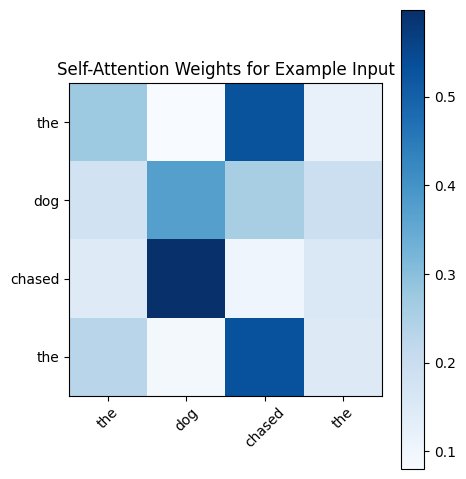

In [25]:
ex_ix = 0
input_ids = inputs[ex_ix]
tokens = [idx2word[i] for i in input_ids]

model.eval()
x_example = torch.tensor([input_ids], dtype=torch.long)  # Add batch dimension
with torch.no_grad():
    logits, attn_weights = model(x_example) 

##plot attention
plot_attention(attn_weights, tokens, title="Self-Attention Weights for Example Input")

### The Training Loop

def train_model(model,loader, loss_fn, optimize, epochs = 20, device = 'cpu'):

    model.to(device)
    for epoch in range(epochs):
        model.train()

        total_loss = 0

        with tqdm(loader, desc = f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()

                logits, _ = model(xb)

                loss = loss_fn(logits, yb)
                
                ## gradient calculated
                loss.backward() 

                ## optimization
                optimizer.step()

                total_loss +=loss.item() * xb.size(0)

                pbar.set_postfix(loss = loss.item())
        
        avg_loss = total_loss/ len(loader.dataset)

        print(f"Epoch {epoch+1}: avg_loss =  {avg_loss:.4f}")

In [26]:
def train_model(model,loader, loss_fn, optimizer, epochs = 20, device = 'cpu'):

    model.to(device)
    for epoch in range(epochs):
        model.train()

        total_loss = 0

        with tqdm(loader, desc = f"Epoch {epoch+1}/{epochs}") as pbar:
            for xb, yb in pbar:
                xb, yb = xb.to(device), yb.to(device)

                optimizer.zero_grad()

                logits, _ = model(xb)

                loss = loss_fn(logits, yb)
                
                ## gradient calculated
                loss.backward() 

                ## optimization
                optimizer.step()

                total_loss +=loss.item() * xb.size(0)

                pbar.set_postfix(loss = loss.item())
        
        avg_loss = total_loss/ len(loader.dataset)



        print(f"Epoch {epoch+1}: avg_loss =  {avg_loss:.4f}")


In [27]:
len(loader)

1

In [43]:
optimizer = optim.Adam(model.parameters(), lr=0.001)

loss_fn = nn.CrossEntropyLoss()

device = 'cuda' if torch.cuda.is_available() else 'cpu'

train_model(model,loader, loss_fn, optimizer, epochs=200, device=device)

Epoch 1/200: 100%|██████████| 1/1 [00:00<00:00, 27.48it/s, loss=0.783]


Epoch 1: avg_loss =  0.7831


Epoch 2/200: 100%|██████████| 1/1 [00:00<00:00, 26.74it/s, loss=0.778]


Epoch 2: avg_loss =  0.7780


Epoch 3/200: 100%|██████████| 1/1 [00:00<00:00, 30.75it/s, loss=0.773]


...

Epoch 198: avg_loss =  0.4877


Epoch 199/200: 100%|██████████| 1/1 [00:00<00:00, 38.14it/s, loss=0.472]


Epoch 199: avg_loss =  0.4720


Epoch 200/200: 100%|██████████| 1/1 [00:00<00:00, 63.74it/s, loss=0.456]

Epoch 200: avg_loss =  0.4559


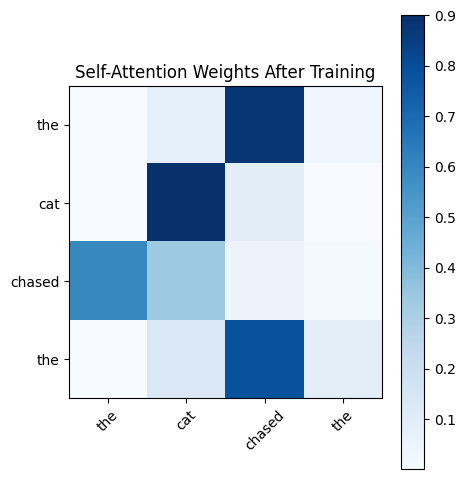

In [47]:
ex_ix = 1
input_ids = inputs[ex_ix]
tokens = [idx2word[i] for i in input_ids]
model.eval()
x_example = torch.tensor([input_ids], dtype=torch.long)  # Add batch dimension
with torch.no_grad():
    logits, attn_weights = model(x_example) 

plot_attention(attn_weights, tokens, title="Self-Attention Weights After Training")

In [48]:
idx2word[logits.argmax(dim=-1).item()]

'mouse'

In [49]:
tokens

['the', 'cat', 'chased', 'the']

In [61]:
## generating text word
def generete_next_words(model, sentence, tokenizer, word2idx, idx2word,max_tokens = 5, seq_len =4, device = 'cpu'):

    model.eval()

    tokens = tokenizer(sentence)

    ## Extract the most recent rokens to fit the models context length 
    for _ in range(max_tokens):
        if len(tokens)>=seq_len:
            window = tokens[-seq_len:]
        else:
            window = ['<pad>']*(seq_len-len(tokens)) + tokens

        input_ids = torch.tensor([[word2idx.get(w, word2idx['<unk>']) for w in window]], dtype = torch.long).to(device)

        with torch.no_grad():
            logits, _ = model(input_ids)

            next_id = logits.argmax(dim = -1).item()
        
        next_word = idx2word[next_id]

        tokens.append(next_word)

    return tokens
    
    

In [73]:
sentence = "the dog chased the"
output  = generete_next_words(model, sentence, tokenizer, word2idx, idx2word, max_tokens = 1, seq_len =4, device = device)    

In [74]:
output

['the', 'dog', 'chased', 'the', 'cat']

In [75]:
print("Generated sequence:", " ".join(output))

Generated sequence: the dog chased the cat
